In [2]:
import kagglehub 
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Đọc dữ liệu
path = kagglehub.dataset_download("ziya07/sustainable-concrete-dataset")
file_path = os.path.join(path, "sustainable_concrete_dataset.csv")

# Đọc dữ liệu từ đường dẫn tự động vừa tải về
df = pd.read_csv(file_path)

# Chạy lệnh hiển thị thông tin chi tiết
print("1. Kích thước (Shape):", df.shape)
print("-" * 40)

print("\n2. Số lượng Missing Value từng cột:")
print(df.isnull().sum())
print("-" * 40)

print("\n3. Thông tin tổng quan (Info):")
df.info()
print("-" * 40)

print("\n4. Thống kê mô tả (Describe):")
print(df.describe())
print("-" * 40)

# ==========================================
# ==========================================

print("\n" + "="*50)
print("📌 KẾT LUẬN CUỐI CÙNG:")
print("="*50)

# Lấy chính xác số hàng và số cột từ df.shape
so_hang, so_cot = df.shape

# Tính tổng số missing value của toàn bộ bảng
tong_missing = df.isnull().sum().sum()

# Đưa ra xác nhận
if so_hang == 1000 and so_cot == 10 and tong_missing == 0:
    print("✅ Xác nhận: 1000 hàng × 10 cột, 0 missing.")
else:
    print(f"❌ Dữ liệu thực tế: {so_hang} hàng × {so_cot} cột, {tong_missing} missing.")
    print("=> Dữ liệu chưa khớp với yêu cầu 1000x10 và 0 missing, hãy kiểm tra lại file!")

1. Kích thước (Shape): (1000, 10)
----------------------------------------

2. Số lượng Missing Value từng cột:
cement                  0
water                   0
superplasticizer        0
coarse_aggregate        0
fine_aggregate          0
age                     0
compressive_strength    0
embodied_CO2            0
energy_consumption      0
resource_consumption    0
dtype: int64
----------------------------------------

3. Thông tin tổng quan (Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cement                1000 non-null   float64
 1   water                 1000 non-null   float64
 2   superplasticizer      1000 non-null   float64
 3   coarse_aggregate      1000 non-null   float64
 4   fine_aggregate        1000 non-null   float64
 5   age                   1000 non-null   int64  
 6   compressive_strength  1

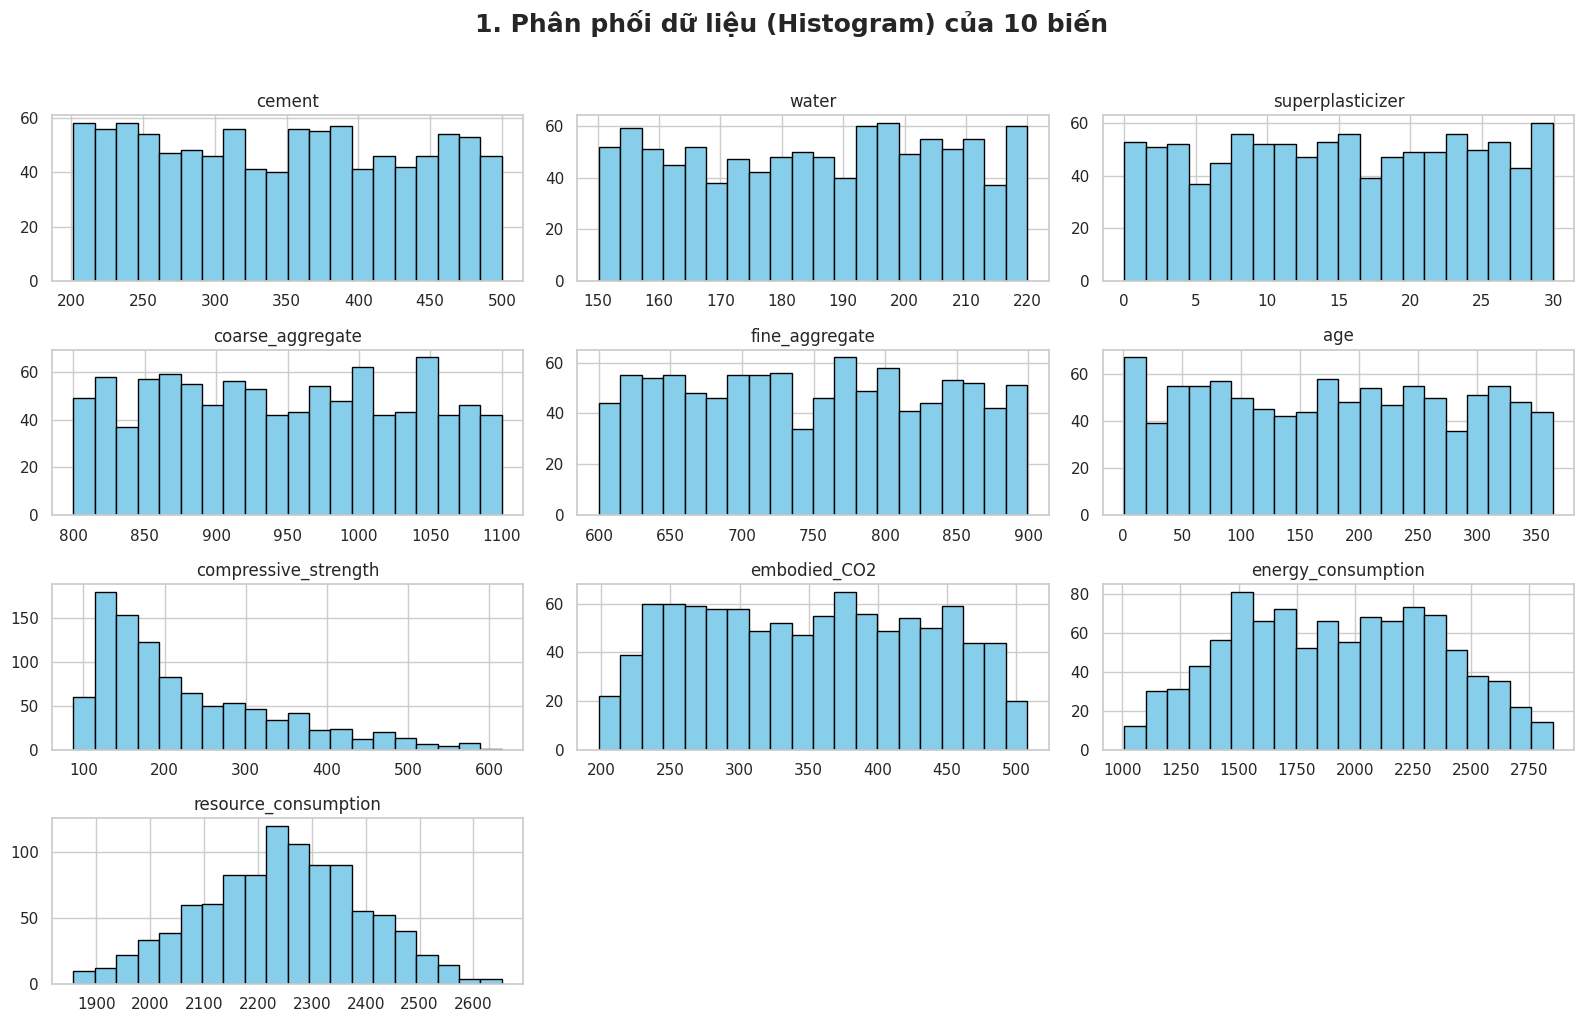

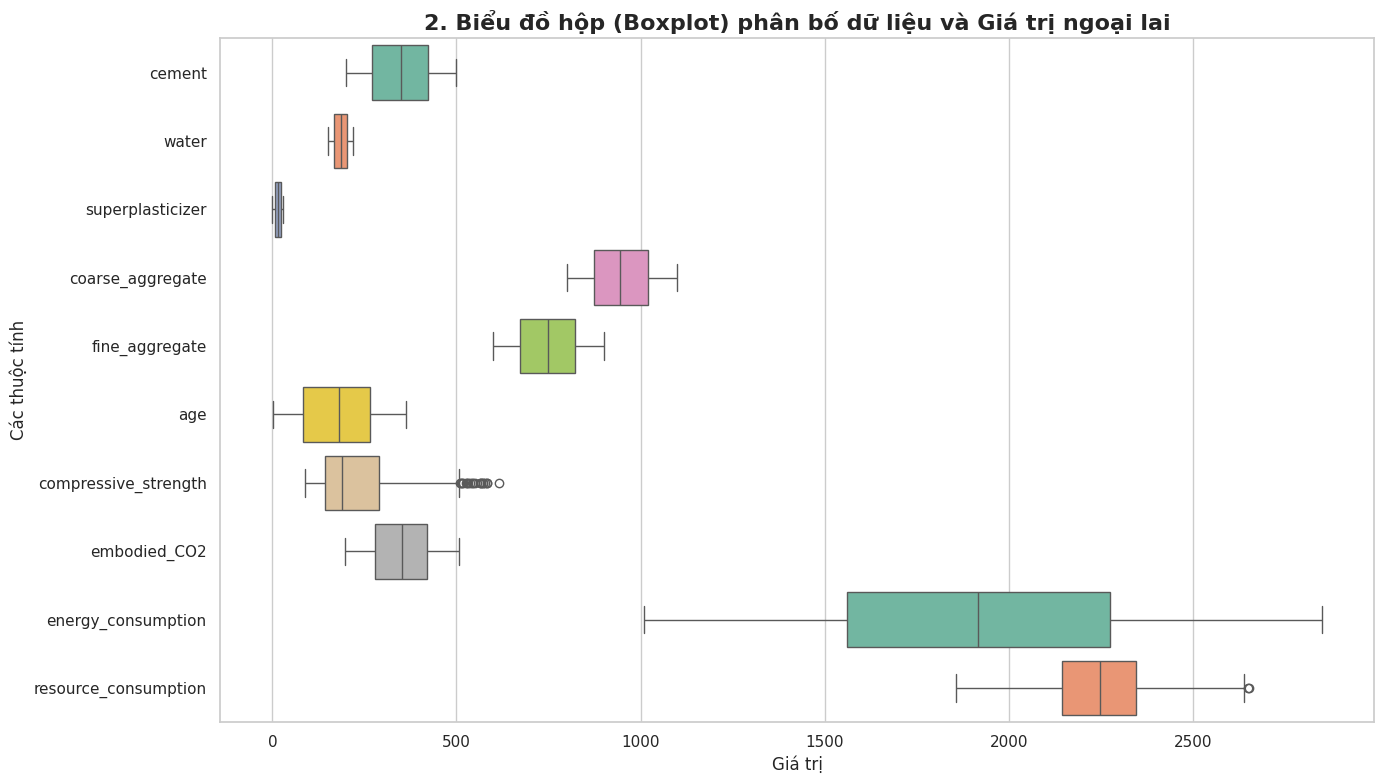

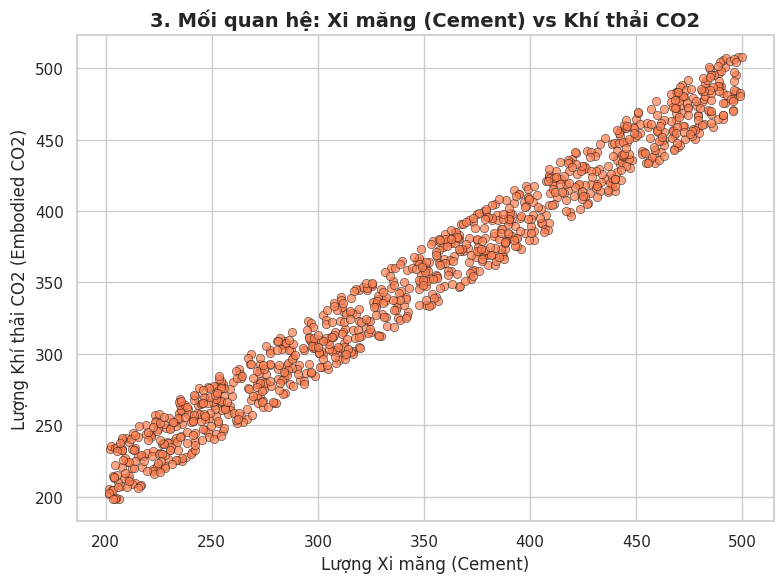

🔍 Nhận xét: Hệ số tương quan Pearson r = 0.987
→ Tương quan RẤT MẠNH: xi măng càng nhiều thì CO2 càng cao


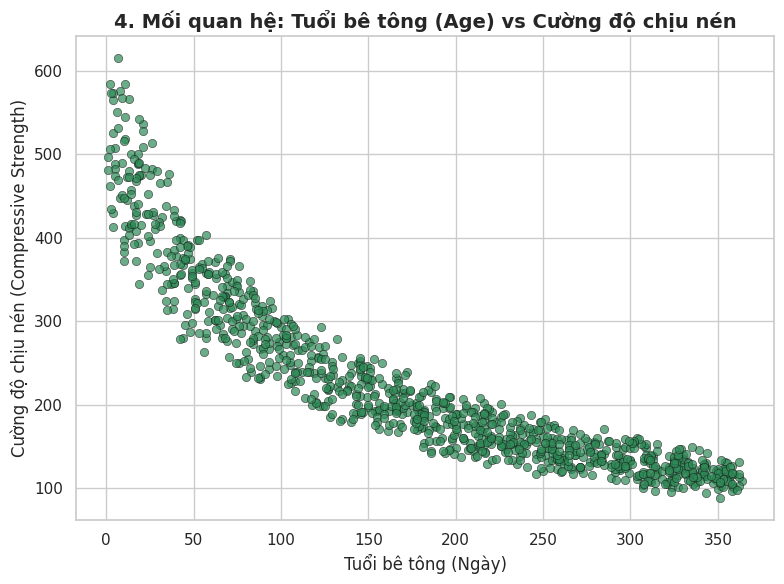

🔍 Nhận xét: Hệ số tương quan Pearson r = -0.901
→ Tương quan yếu: tuổi bê tông không ảnh hưởng tuyến tính rõ đến cường độ


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách (style) cho các biểu đồ
sns.set_theme(style="whitegrid")

# ==========================================
# BIỂU ĐỒ 1: HISTOGRAM CHO TOÀN BỘ 10 CỘT
# ==========================================
# figsize=(15, 10) giúp khung hình đủ rộng để chứa 10 biểu đồ nhỏ không bị đè lên nhau
df.hist(figsize=(16, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("1. Phân phối dữ liệu (Histogram) của 10 biến", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 2: BOXPLOT KIỂM TRA OUTLIERS (GIÁ TRỊ NGOẠI LAI)
# ==========================================
plt.figure(figsize=(14, 8))
# Dùng orient="h" để vẽ boxplot nằm ngang cho dễ đọc tên cột
sns.boxplot(data=df, orient="h", palette="Set2")
plt.title("2. Biểu đồ hộp (Boxplot) phân bố dữ liệu và Giá trị ngoại lai", fontsize=16, fontweight='bold')
plt.xlabel("Giá trị")
plt.ylabel("Các thuộc tính")
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 3: SCATTER PLOT - CEMENT vs EMBODIED CO2
# ==========================================
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='cement', y='embodied_CO2', alpha=0.7, color='coral', edgecolor='k')
plt.title("3. Mối quan hệ: Xi măng (Cement) vs Khí thải CO2", fontsize=14, fontweight='bold')
plt.xlabel("Lượng Xi măng (Cement)")
plt.ylabel("Lượng Khí thải CO2 (Embodied CO2)")
plt.tight_layout()
plt.show()

r_cement_co2 = df['cement'].corr(df['embodied_CO2'])
print(f"🔍 Nhận xét: Hệ số tương quan Pearson r = {r_cement_co2:.3f}")
print("→ Tương quan RẤT MẠNH: xi măng càng nhiều thì CO2 càng cao")

# ==========================================
# BIỂU ĐỒ 4: SCATTER PLOT - AGE vs COMPRESSIVE STRENGTH
# ==========================================
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='compressive_strength', alpha=0.7, color='seagreen', edgecolor='k')
plt.title("4. Mối quan hệ: Tuổi bê tông (Age) vs Cường độ chịu nén", fontsize=14, fontweight='bold')
plt.xlabel("Tuổi bê tông (Ngày)")
plt.ylabel("Cường độ chịu nén (Compressive Strength)")
plt.tight_layout()
plt.show()

r_age_str = df['age'].corr(df['compressive_strength'])
print(f"🔍 Nhận xét: Hệ số tương quan Pearson r = {r_age_str:.3f}")
print("→ Tương quan yếu: tuổi bê tông không ảnh hưởng tuyến tính rõ đến cường độ")

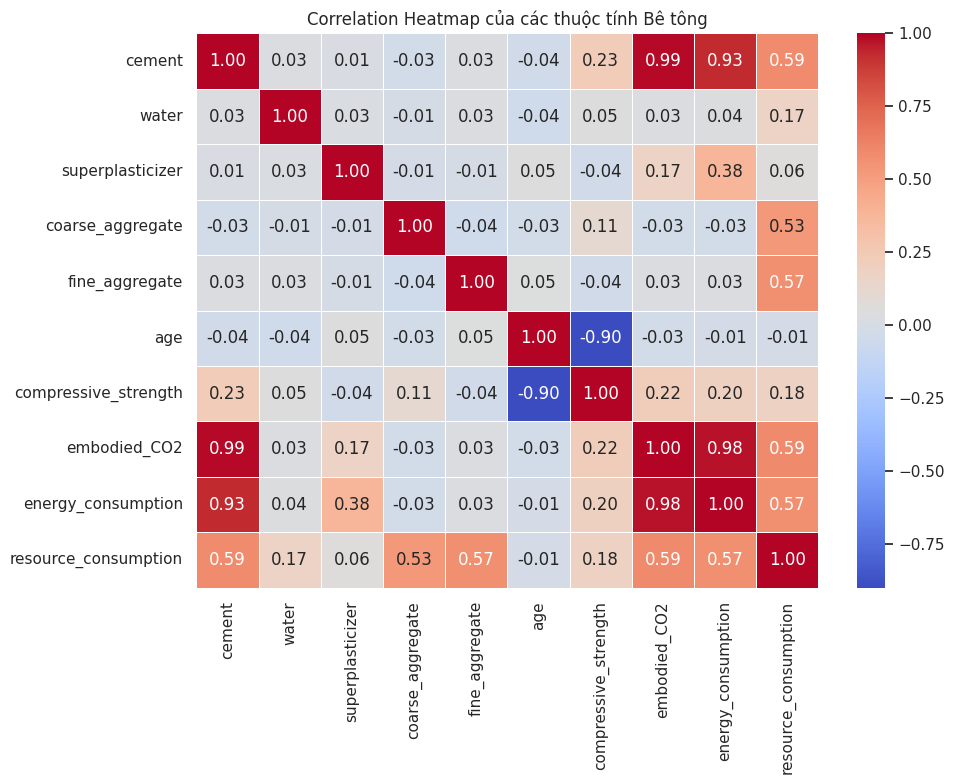


📊 NHẬN XÉT CORRELATION HEATMAP

🏗️  Biến ảnh hưởng tới compressive_strength (cường độ nén):
   age                      : r = -0.90  🔴 Mạnh
   cement                   : r = +0.23  🟢 Yếu
   embodied_CO2             : r = +0.22  🟢 Yếu
   energy_consumption       : r = +0.20  🟢 Yếu
   resource_consumption     : r = +0.18  🟢 Yếu
   coarse_aggregate         : r = +0.11  🟢 Yếu
   water                    : r = +0.05  🟢 Yếu
   superplasticizer         : r = -0.04  🟢 Yếu
   fine_aggregate           : r = -0.04  🟢 Yếu

🌿  Biến ảnh hưởng tới embodied_CO2 (phát thải):
   cement                   : r = +0.99  🔴 Mạnh
   energy_consumption       : r = +0.98  🔴 Mạnh
   resource_consumption     : r = +0.59  🔴 Mạnh
   compressive_strength     : r = +0.22  🟢 Yếu
   superplasticizer         : r = +0.17  🟢 Yếu
   fine_aggregate           : r = +0.03  🟢 Yếu
   water                    : r = +0.03  🟢 Yếu
   coarse_aggregate         : r = -0.03  🟢 Yếu
   age                      : r = -0.03  🟢 Yếu


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ Correlation Heatmap
plt.figure(figsize=(10, 8)) # Tạo khung hình kích thước 10x8
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap của các thuộc tính Bê tông')
plt.tight_layout()
plt.show()
# Phần nhận xét:
print("\n📊 NHẬN XÉT CORRELATION HEATMAP")
print("=" * 50)

corr_strength = corr_matrix['compressive_strength'].drop('compressive_strength')
corr_strength = corr_strength.abs().sort_values(ascending=False)

print("\n🏗️  Biến ảnh hưởng tới compressive_strength (cường độ nén):")
for col, val in corr_strength.items():
    r_val = corr_matrix.loc[col, 'compressive_strength']
    muc = "🔴 Mạnh" if abs(r_val) > 0.5 else ("🟡 Trung bình" if abs(r_val) > 0.3 else "🟢 Yếu")
    print(f"   {col:<25}: r = {r_val:+.2f}  {muc}")

corr_co2 = corr_matrix['embodied_CO2'].drop('embodied_CO2')
corr_co2 = corr_co2.abs().sort_values(ascending=False)

print("\n🌿  Biến ảnh hưởng tới embodied_CO2 (phát thải):")
for col, val in corr_co2.items():
    r_val = corr_matrix.loc[col, 'embodied_CO2']
    muc = "🔴 Mạnh" if abs(r_val) > 0.5 else ("🟡 Trung bình" if abs(r_val) > 0.3 else "🟢 Yếu")
    print(f"   {col:<25}: r = {r_val:+.2f}  {muc}")

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Tách biến (X) và Mục tiêu (y)
X  = df.drop(columns=['compressive_strength', 'embodied_CO2']) 
y = df['compressive_strength']

# 2. Chuẩn hóa (Scaling) toàn bộ tập X bằng StandardScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

# 3. Chia tập Train / Test với tỷ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Xuất toàn bộ file ra thư mục
X_scaled.to_csv('X_scaled.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
